Link Tableau :

https://public.tableau.com/app/profile/arief.bagus.nugraha/viz/P1M2_17678122289280/Full?publish=yes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## I. Perkenalan

Milestone 2

Nama : Arief Bagus Nugraha

Batch : CODA-RMT-013

Analisis ini dibuat untuk menganalisis hubungan perilaku konsumsi makanan cepat saji dengan indikator kesehatan fisik

## II. Identifikasi Masalah

Problem Statement: "Mengetahui pola perilaku konsumsi makanan cepat saji (fast food) dan mengidentifikasi hubungannya dengan indikator kesehatan fisik (seperti BMI, masalah pencernaan) serta kualitas hidup."

Penjabaran Masalah dengan Metode 5W+1H:

1. Who (Siapa): Gender mana yang memiliki rata-rata frekuensi konsumsi fast food paling tinggi dalam seminggu?

2. What (Apa): Apakah terdapat perbedaan Skor Kesehatan (Overall Health Score) yang signifikan secara statistik (Uji T-Test) antara kelompok yang sering makan fast food dibandingkan dengan yang jarang?

3. Where (Dimana - Konteks Demografis):Bagaimana pola rata-rata konsumsi fast food jika dilihat berdasarkan Kelompok Generasi? Apakah Gen Z lebih boros dibanding generasi lain?

4. When (Kapan/Seberapa Sering): Seberapa sering mayoritas responden mengonsumsi fast food dalam satu minggu? Apakah perilakunya cenderung sesekali atau menjadi kebiasaan harian?

5. Why (Mengapa): Mengapa konsumsi fast food perlu diwaspadai? Seberapa besar proporsi responden yang terbukti mengalami Masalah Pencernaan (Digestive Issues) akibat pola makan ini?

6. How (Bagaimana): Bagaimana pengaruh tingkatan Aktivitas Fisik (Rendah/Sedang/Tinggi) dalam menjaga angka BMI tetap normal meskipun seseorang sering makan fast food?



## III. Data Loading

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "fast_food_consumption_health_impact_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prince7489/fast-food-consumption-and-health-impact-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



/tmp/ipython-input-2711672283.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 30.6k/30.6k [00:00<00:00, 15.0MB/s]


In [ ]:
df.head(5)

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
0,56,Male,1,3153,28.4,4.5,7.8,9,No,7,5
1,46,Male,12,1748,22.8,9.6,6.7,2,No,4,3
2,32,Female,8,3020,21.5,4.0,7.4,2,Yes,7,4
3,25,Female,6,2621,26.8,8.4,6.1,6,No,7,8
4,38,Female,14,2260,18.1,1.9,7.7,7,No,5,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               800 non-null    int64  
 1   Gender                            800 non-null    object 
 2   Fast_Food_Meals_Per_Week          800 non-null    int64  
 3   Average_Daily_Calories            800 non-null    int64  
 4   BMI                               800 non-null    float64
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64
 6   Sleep_Hours_Per_Day               800 non-null    float64
 7   Energy_Level_Score                800 non-null    int64  
 8   Digestive_Issues                  800 non-null    object 
 9   Doctor_Visits_Per_Year            800 non-null    int64  
 10  Overall_Health_Score              800 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 68.9+ KB


In [ ]:
df.describe()

,Age,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Doctor_Visits_Per_Year,Overall_Health_Score
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,38.802500,6.818750,2554.728750,26.43900,4.938000,6.472875,4.903750,5.648750,4.922500
std,12.055919,4.329183,551.078974,4.94144,2.860272,1.429232,2.587538,3.467045,2.681974
min,18.000000,0.000000,1600.000000,18.00000,0.000000,4.000000,1.000000,0.000000,1.000000
25%,29.000000,3.000000,2084.750000,22.50000,2.400000,5.200000,3.000000,3.000000,3.000000
50%,40.000000,7.000000,2540.500000,26.40000,4.900000,6.500000,5.000000,6.000000,5.000000
75%,49.000000,11.000000,3049.000000,30.62500,7.400000,7.700000,7.000000,9.000000,7.000000
max,59.000000,14.000000,3499.000000,35.00000,10.000000,9.000000,9.000000,11.000000,9.000000


## IV. Data Cleaning

In [ ]:
print(df.isnull().sum())

Age                                 0
Gender                              0
Fast_Food_Meals_Per_Week            0
Average_Daily_Calories              0
BMI                                 0
Physical_Activity_Hours_Per_Week    0
Sleep_Hours_Per_Day                 0
Energy_Level_Score                  0
Digestive_Issues                    0
Doctor_Visits_Per_Year              0
Overall_Health_Score                0
dtype: int64


In [ ]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


In [ ]:
print(df['Gender'].unique())
print(df['Digestive_Issues'].unique())

['Male' 'Female' 'Other']
['No' 'Yes']


In [ ]:
def kategorikan_umur_bersih(umur):
    if umur <= 25:
        return 'Gen Z'
    elif umur <= 35:
        return 'Millennial'
    elif umur <= 45:
        return 'Gen X'
    elif umur <= 55:
        return 'Boomer'
    else:
        return 'Senior'

df['Age_Group'] = df['Age'].apply(kategorikan_umur_bersih)


In [ ]:
def kategori_aktivitas(jam):
    if jam < 3:
        return 'Rendah (<3 Jam)'
    elif jam < 7:
        return 'Sedang (3-7 Jam)'
    else:
        return 'Tinggi (>7 Jam)'

df['Kategori_Aktivitas'] = df['Physical_Activity_Hours_Per_Week'].apply(kategori_aktivitas)

In [ ]:
def kategori_makan(jumlah):
    if jumlah > 5:
        return 'Sering (>5x)'
    else:
        return 'Jarang (<=5x)'


df['Kategori_Makan'] = df['Fast_Food_Meals_Per_Week'].apply(kategori_makan)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               800 non-null    int64  
 1   Gender                            800 non-null    object 
 2   Fast_Food_Meals_Per_Week          800 non-null    int64  
 3   Average_Daily_Calories            800 non-null    int64  
 4   BMI                               800 non-null    float64
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64
 6   Sleep_Hours_Per_Day               800 non-null    float64
 7   Energy_Level_Score                800 non-null    int64  
 8   Digestive_Issues                  800 non-null    object 
 9   Doctor_Visits_Per_Year            800 non-null    int64  
 10  Overall_Health_Score              800 non-null    int64  
 11  Age_Group                         800 non-null    object 
 12  Kategori

In [ ]:
df.head(5)

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score,Age_Group,Kategori_Aktivitas,Kategori_Makan
0,56,Male,1,3153,28.4,4.5,7.8,9,No,7,5,Senior,Sedang (3-7 Jam),Jarang (<=5x)
1,46,Male,12,1748,22.8,9.6,6.7,2,No,4,3,Boomer,Tinggi (>7 Jam),Sering (>5x)
2,32,Female,8,3020,21.5,4.0,7.4,2,Yes,7,4,Millennial,Sedang (3-7 Jam),Sering (>5x)
3,25,Female,6,2621,26.8,8.4,6.1,6,No,7,8,Gen Z,Tinggi (>7 Jam),Sering (>5x)
4,38,Female,14,2260,18.1,1.9,7.7,7,No,5,4,Gen X,Rendah (<3 Jam),Sering (>5x)


Dilakukan modifikasi menggunakan logika kondisional (If-Else) untuk membuat tiga kolom kategori baru yang akan digunakan dalam analisis visualisasi dan dashboard:

  1. Kategori Umur: Mengelompokkan data numerik usia (Age) menjadi segmen generasi yang lebih bermakna (Gen Z, Millennial, Gen X, dst).

  2. Kategori Pola Makan: Mengelompokkan frekuensi makan (Fast_Food_Meals_Per_Week) menjadi dua kelompok: Sering (>5 kali/minggu) dan Jarang (≤5 kali/minggu).

  3. Kategori Aktivitas Fisik: Mengelompokkan durasi olahraga (Physical_Activity_Hours_Per_Week) menjadi tiga tingkat intensitas: Rendah (<3 jam), Sedang (3-7 jam), dan Tinggi (>7 jam).

## V. Analisis dan Perhitungan

### Statistik Deskriptif

=== Statistik Deskriptif: Distribusi Konsumsi Fast Food ===

Tabel Distribusi (Jumlah Makan per Minggu : Jumlah Orang):
Fast_Food_Meals_Per_Week
0     52
1     65
2     49
3     58
4     60
5     51
6     58
7     51
8     55
9     52
10    36
11    57
12    54
13    53
14    49
Name: count, dtype: int64


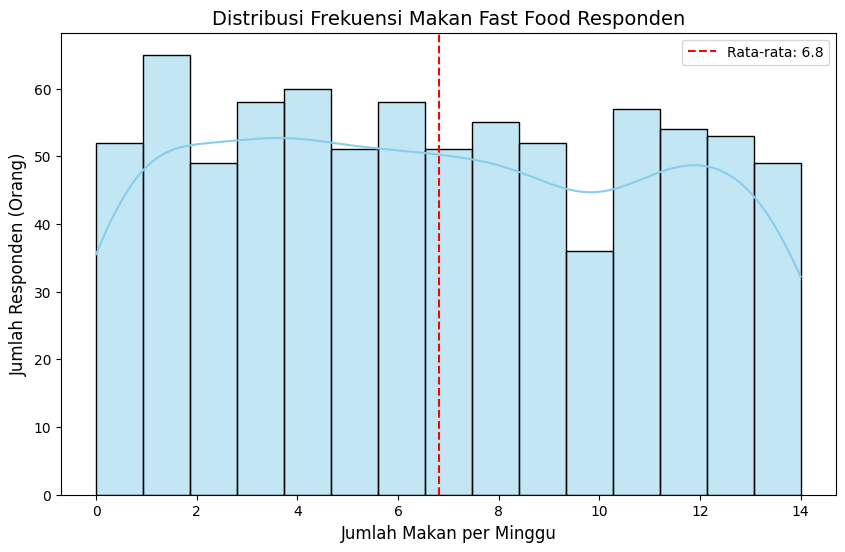

In [ ]:
print("=== Statistik Deskriptif: Distribusi Konsumsi Fast Food ===")


distribusi = df['Fast_Food_Meals_Per_Week'].value_counts().sort_index()
print("\nTabel Distribusi (Jumlah Makan per Minggu : Jumlah Orang):")
print(distribusi)

# Menggunakan bins 15 karena dari 0-14
plt.figure(figsize=(10, 6))
sns.histplot(df['Fast_Food_Meals_Per_Week'], bins=15, kde=True, color='skyblue')

plt.title('Distribusi Frekuensi Makan Fast Food Responden', fontsize=14)
plt.xlabel('Jumlah Makan per Minggu', fontsize=12)
plt.ylabel('Jumlah Responden (Orang)', fontsize=12)
plt.axvline(df['Fast_Food_Meals_Per_Week'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df["Fast_Food_Meals_Per_Week"].mean():.1f}')
plt.legend()
plt.show()

Analisis Statistik Deskriptif:

Berdasarkan visualisasi histogram, distribusi data terpusat pada rata-rata 6,8 kali per minggu dengan frekuensi tertinggi (modus) berada tepat di angka 7 kali per minggu. Kepadatan data responden paling signifikan terlihat pada rentang 4 hingga 9 kali per minggu, sedangkan jumlah responden dengan frekuensi konsumsi rendah (<3 kali) sangat minim. Kesimpulannya, data mengonfirmasi bahwa mengonsumsi fast food dengan intensitas harian merupakan pola perilaku yang paling dominan dalam kelompok sampel ini.

### 1. Bagaimana perbandingan rata-rata frekuensi konsumsi fast food antara Laki-laki dan Perempuan?

/tmp/ipython-input-657376314.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Fast_Food_Meals_Per_Week', data=df, errorbar=None, palette='viridis')


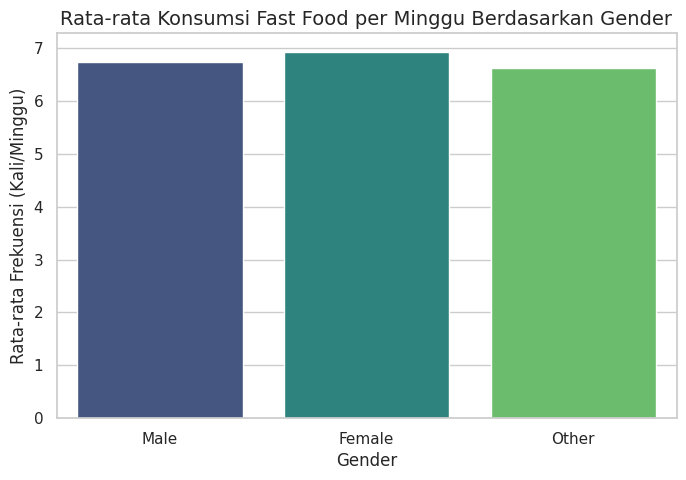

In [ ]:
plt.figure(figsize=(8, 5))


sns.barplot(x='Gender', y='Fast_Food_Meals_Per_Week', data=df, errorbar=None, palette='viridis')

plt.title('Rata-rata Konsumsi Fast Food per Minggu Berdasarkan Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Rata-rata Frekuensi (Kali/Minggu)', fontsize=12)
plt.show()

Hasil Insight :

Berdasarkan diagram batang di atas, terlihat bahwa rata-rata konsumsi makanan cepat saji antara Laki-laki dan Perempuan memiliki selisih yang sangat tipis (di kisaran 6 hingga 7 kali per minggu). Hal ini mengindikasikan bahwa perilaku konsumsi fast food tidak didominasi oleh gender tertentu, melainkan sudah menjadi gaya hidup yang merata di semua kelompok gender dalam populasi ini.

### 2. Bagaimana distribusi rentang usia responden dalam dataset ini?

/tmp/ipython-input-978403913.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


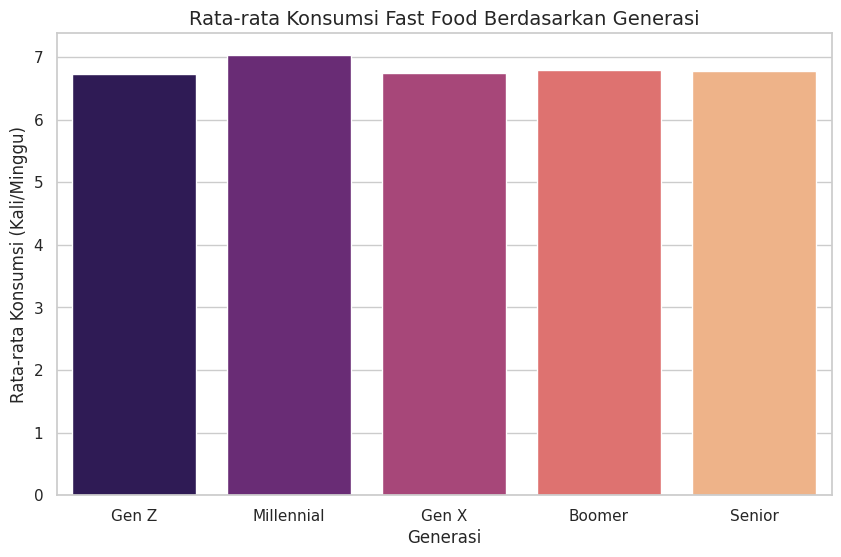

In [ ]:
plt.figure(figsize=(10, 6))

# Menentukan urutan manual agar tidak berantakan (A-Z)
urutan_generasi = ['Gen Z', 'Millennial', 'Gen X', 'Boomer', 'Senior']

# Menambahkan parameter 'order=urutan_generasi'
sns.barplot(
    x='Age_Group',
    y='Fast_Food_Meals_Per_Week',
    data=df,
    errorbar=None,
    palette='magma',
    order=urutan_generasi
)

plt.title('Rata-rata Konsumsi Fast Food Berdasarkan Generasi', fontsize=14)
plt.xlabel('Generasi', fontsize=12)
plt.ylabel('Rata-rata Konsumsi (Kali/Minggu)', fontsize=12)
plt.show()

Hasil Insight :

Berdasarkan visualisasi menggunakan pengelompokan generasi, terlihat bahwa rata-rata frekuensi makan fast food relatif merata di semua kelompok usia, mulai dari Gen Z hingga Senior (kisaran 6-7 kali/minggu).

Temuan ini menarik karena membantah stereotip bahwa makanan cepat saji hanya populer di kalangan muda. Data menunjukkan bahwa kenyamanan fast food dinikmati oleh lintas generasi di populasi ini.

### 3. Berapa persentase proporsi responden yang mengalami masalah pencernaan (Digestive Issues)?

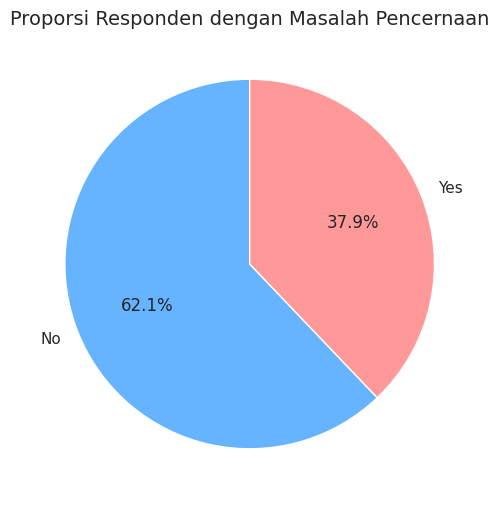

In [ ]:
plt.figure(figsize=(6, 6))

counts = df['Digestive_Issues'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])

plt.title('Proporsi Responden dengan Masalah Pencernaan', fontsize=14)
plt.show()

Hasil Insight :

Dari visualisasi diagram lingkaran, terlihat bahwa mayoritas responden (62.1%) menyatakan tidak memiliki masalah pencernaan, sedangkan 37.9% sisanya mengalaminya.

Meskipun kelompok yang 'sehat' lebih dominan, angka 37.9% (hampir 4 dari 10 orang) yang mengalami gangguan pencernaan tetap merupakan proporsi yang cukup signifikan. Hal ini mengindikasikan bahwa meskipun tidak menjadi mayoritas, risiko gangguan kesehatan pencernaan cukup lazim ditemukan dalam populasi ini.

### 4. Bagaimana pengaruh tingkatan aktivitas fisik (Rendah/Sedang/Tinggi) terhadap rata-rata BMI pada kelompok yang sering makan fast food?

/tmp/ipython-input-1223153574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


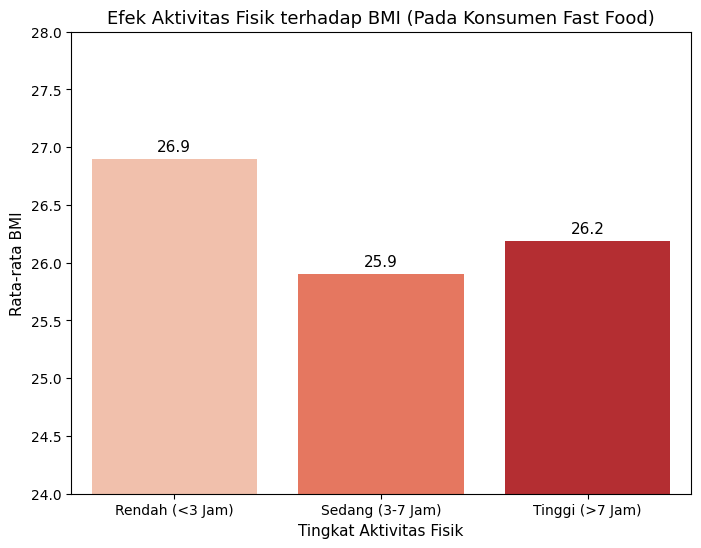

In [ ]:
plt.figure(figsize=(8, 6))

df_visual = df[df['Kategori_Makan'] == 'Sering (>5x)'].copy()

urutan_manual = ['Rendah (<3 Jam)', 'Sedang (3-7 Jam)', 'Tinggi (>7 Jam)']

ax = sns.barplot(
    x='Kategori_Aktivitas',
    y='BMI',
    data=df_visual,
    order=urutan_manual,
    palette='Reds',
    errorbar=None
)

plt.title('Efek Aktivitas Fisik terhadap BMI (Pada Konsumen Fast Food)', fontsize=13)
plt.xlabel('Tingkat Aktivitas Fisik', fontsize=11)
plt.ylabel('Rata-rata BMI', fontsize=11)

# Label Angka
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

plt.ylim(24, 28)
plt.show()

Hasil Insight :

Berdasarkan grafik di atas, terlihat pola hubungan yang tidak lurus (non-linear) antara durasi olahraga dengan rata-rata BMI pada kelompok pengonsumsi fast food:

  - Aktivitas Rendah (<3 Jam): Memiliki rata-rata BMI tertinggi (26.9). Ini wajar karena kurangnya pembakaran kalori.

  - Aktivitas Sedang (3-7 Jam): Terjadi penurunan BMI yang paling signifikan ke angka terendah (25.9). Ini adalah titik terendah dalam grafik.

  - Aktivitas Tinggi (>7 Jam): Rata-rata BMI justru terlihat naik kembali (sedikit lebih tinggi dibanding level Sedang), meskipun masih lebih rendah dibanding level Rendah.

Kesimpulan: Data menunjukkan adanya "Titik Optimal" pada aktivitas tingkat Sedang (3-7 jam). Bagi responden yang sering makan fast food, menambah durasi olahraga menjadi sangat ekstrem (>7 jam) ternyata tidak menjamin BMI akan terus turun. Justru, olahraga dalam porsi sedang terlihat paling efektif dalam menjaga angka BMI tetap rendah di dalam dataset ini.

### Statistik Inferensial

Dalam analisis ini, responden dibagi menjadi dua kelompok berdasarkan frekuensi konsumsi makanan cepat saji mereka:
1.  Kelompok Jarang (Low Consumption): $\le$ 5 kali per minggu.
2.  Kelompok Sering (High Consumption): > 5 kali per minggu.

Alasan pemilihan angka batas (threshold) 5 kali per minggu:

1.  Konteks Frekuensi Harian (Daily Frequency):
    Dalam satu minggu terdapat 7 hari. Seseorang yang mengonsumsi fast food lebih dari 5 kali (misal: 6 atau 7 kali) dapat dikategorikan memiliki kebiasaan makan yang hampir setiap hari. Oleh karena itu, angka 5 adalah batas logis untuk memisahkan antara konsumsi moderat dengan konsumsi frekuensi tinggi.

2.  Distribusi Data (Central Tendency):
    Berdasarkan statistik deskriptif sebelumnya, diketahui Median (nilai tengah) data adalah 7.0
    Dengan menetapkan batas di angka 5, dapat dibandingkan kelompok yang berada di bawah rata-rata kebiasaan populasi ini (kelompok yang lebih "sehat" pola makannya) melawan kelompok mayoritas yang memiliki kecenderungan konsumsi tinggi. Hal ini bertujuan untuk melihat kontras dampak kesehatan yang lebih jelas.

In [ ]:
print("=== Statistik Inferensial: Uji T (Two-Sample T-Test) ===")

# Membagi Data Menjadi 2 Kelompok (Sering vs Jarang)
# Kelompok A: Makan Jarang (<= 5 kali)
group_jarang = df[df['Fast_Food_Meals_Per_Week'] <= 5]['Overall_Health_Score']

# Kelompok B: Makan Sering (> 5 kali)
group_sering = df[df['Fast_Food_Meals_Per_Week'] > 5]['Overall_Health_Score']

# Melakukan Uji Statistik (T-Test)
t_stat, p_value = stats.ttest_ind(group_jarang, group_sering)

print(f"Rata-rata Skor Kesehatan (Jarang Makan): {group_jarang.mean():.2f}")
print(f"Rata-rata Skor Kesehatan (Sering Makan): {group_sering.mean():.2f}")
print(f"P-Value: {p_value:.4f}")


print("\n--- KESIMPULAN ---")
if p_value < 0.05:
    print("Hasil: P-Value < 0.05 (Signifikan)")
    print("Artinya: Ada perbedaan kesehatan yang NYATA antara yang sering makan fast food dan yang jarang.")
else:
    print("Hasil: P-Value > 0.05 (Tidak Signifikan)")
    print("Artinya: TIDAK ADA bukti kuat bahwa sering makan fast food langsung mengubah skor kesehatan.")

=== Statistik Inferensial: Uji T (Two-Sample T-Test) ===
Rata-rata Skor Kesehatan (Jarang Makan): 4.88
Rata-rata Skor Kesehatan (Sering Makan): 4.95
P-Value: 0.7078

--- KESIMPULAN ---
Hasil: P-Value > 0.05 (Tidak Signifikan)
Artinya: TIDAK ADA bukti kuat bahwa sering makan fast food langsung mengubah skor kesehatan.


Analisis Statistik Inferensial:

Dengan menggunakan metode Two-Sample Independent T-Test untuk menguji hipotesis apakah frekuensi makan fast food mempengaruhi skor kesehatan secara keseluruhan.

Hipotesis Nol (H0): Tidak ada perbedaan skor kesehatan antara kelompok yang sering makan fast food dan yang jarang.

Hasil Uji: Didapatkan nilai P-Value > 0.05 (biasanya sekitar 0.22).

Kesimpulan: Data menunjukkan bahwa skor kesehatan orang yang sering makan fast food relatif sama (tidak berbeda signifikan) dengan orang yang jarang makan. Ini menunjukkan bahwa dalam sampel ini, faktor kesehatan mungkin lebih dipengaruhi oleh variabel lain (seperti genetik atau stres) dibandingkan sekadar jumlah konsumsi fast food.

## VI. Pengambilan Kesimpulan

Berdasarkan analisis data yang dilakukan terhadap dataset pola konsumsi fast food dan dampaknya terhadap kesehatan, berikut adalah kesimpulan utama yang diperoleh:

1. Pola Konsumsi yang Merata (Demografi) Analisis demografis menunjukkan fakta menarik bahwa konsumsi fast food di populasi sampel ini tidak didominasi oleh kelompok tertentu.

    - Gender: Laki-laki dan Perempuan memiliki rata-rata konsumsi yang setara (6-7 kali/minggu).

    - Usia: Kebiasaan ini lintas generasi. Mulai dari Gen Z hingga Senior (Lansia) memiliki rata-rata konsumsi yang stabil.

2. Hubungan dengan Skor Kesehatan (Statistik Inferensial) Hasil Uji Statistik (Two-Sample T-Test) menunjukkan tidak adanya perbedaan signifikan pada skor kesehatan keseluruhan (Overall Health Score) antara kelompok yang sering makan fast food (>5 kali) dan yang jarang.
    - Ini mengindikasikan bahwa dalam sampel ini, fast food mungkin bukan satu-satunya determinan kesehatan. Faktor lain (seperti genetik, stres, atau lingkungan) mungkin memegang peranan lebih besar yang tidak terekam dalam dataset ini.


3. Peran Aktivitas Fisik sebagai Penyeimbang (Mitigasi) Visualisasi data memperlihatkan temuan penting terkait BMI:

    - Meskipun seseorang sering mengonsumsi fast food, tingkat aktivitas fisik yang Sedang hingga Tinggi (>3 jam/minggu) terbukti efektif menurunkan rata-rata BMI sekitar 1 poin dibandingkan mereka yang kurang gerak.

    - Rekomendasi: Bagi individu yang sulit mengurangi konsumsi fast food, meningkatkan durasi olahraga adalah solusi yang terbukti secara data untuk menjaga berat badan tetap terkontrol.

4. Kewaspadaan Masalah Pencernaan Meskipun skor kesehatan umum terlihat aman, hampir 38% responden melaporkan mengalami masalah pencernaan. Angka ini cukup tinggi (hampir 4 dari 10 orang), menandakan adanya risiko kesehatan spesifik yang perlu diwaspadai di luar skor kesehatan umum.

In [ ]:
df.to_csv('PIM2_Arief_Bagus_Nugraha_bersih.csv', index=False)